# 数据集

In [114]:
cwd = os.getcwd()
project_dir = os.path.dirname(cwd)
dataset_dir = os.path.join(project_dir, "dataset")
cifar10_dir = os.path.join(dataset_dir, "cifar10")

In [115]:
from torchvision import datasets, transforms

In [116]:
transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(root = cifar10_dir, train = False, download = True, transform = transform)
training_dataset = datasets.CIFAR10(root = cifar10_dir, train = True, download = True, transform = transform)

Files already downloaded and verified
Files already downloaded and verified


In [117]:
print(f"test dataset size: {len(test_dataset)}")
print(f"training dataset size: {len(training_dataset)}")

test dataset size: 10000
training dataset size: 50000


In [118]:
img0, label0 = training_dataset[0]
print(f"image tensor shape: {img0.shape}")
print(f"label: {label0}")

image tensor shape: torch.Size([3, 32, 32])
label: 6


In [119]:
import matplotlib.pyplot as plt
import numpy as np

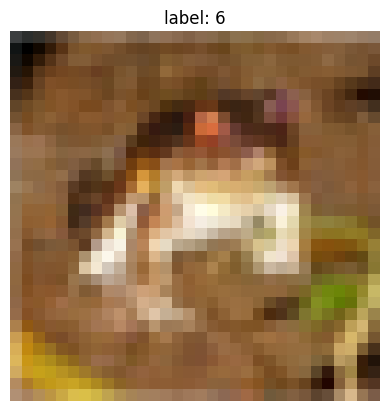

In [120]:
def show_image(img_tensor, label):
    img = img_tensor.permute(1, 2, 0).numpy()  # [C, H, W] -> [H, W, C]
    plt.axis("off")
    plt.imshow(img)
    plt.title(f"label: {label}")

show_image(img0, label0)
plt.show()

# 验证

In [121]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [122]:
class ConvBody(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size = 3, padding = 1), # [3, 32, 32] -> [32, 32, 32]
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1), # -> [64, 32, 32]
            nn.ReLU(),

            nn.MaxPool2d(2), # -> [64, 16, 16]

            nn.Conv2d(64, 128, kernel_size = 3, padding = 1), # -> [128, 16, 16]
            nn.ReLU(),

            nn.MaxPool2d(2), # -> [128, 8, 8]
        )

        self.fc = nn.Linear(128 * 8 * 8, 256)

    def flatten(self, x):
        return x.view(x.size(0), -1) 

    def forward(self, x):
        return self.fc(self.flatten(self.features(x)))


class ClassificationHead(nn.Module):
    def __init__(self, class_cnt):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Linear(256, class_cnt)
        )

    def forward(self, x):
        return self.classifier(x)


class CNNModel(nn.Module):
    def __init__(self, class_cnt):
        super().__init__()

        self.body = ConvBody()
        self.head = ClassificationHead(class_cnt)

    def forward(self, x):
        return self.head(self.body(x))

## 测试

In [123]:
from torch.utils.data import DataLoader

In [124]:
def test_cnn(device, model, dataset, batch_size = 128):
    model.eval()
    model.to(device)

    dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = False)

    sample_cnt = 0
    correct_cnt = 0
    with torch.no_grad():
        for imgs, tgts in dataloader:
            imgs = imgs.to(device)
            tgts = tgts.to(device)
            pred = model(imgs).argmax(dim = -1)

            sample_cnt += tgts.size(0)
            correct_cnt += (pred == tgts).sum().item()
            
    acc = correct_cnt / sample_cnt
    return acc

## 训练

In [125]:
import random

def set_rand_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"rand seed: {seed}")

In [126]:
def train_cnn_one_epoch(device, model, dataloader, optimizer):
    model.train()
    model.to(device)

    total_loss = 0
    sample_cnt = 0
    correct_cnt = 0
    for imgs, tgts in dataloader:
        imgs = imgs.to(device)
        tgts = tgts.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = F.cross_entropy(logits, tgts)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * tgts.size(0)
        sample_cnt += tgts.size(0)
        correct_cnt += (logits.argmax(dim = -1) == tgts).sum().item()

    avg_loss = total_loss / sample_cnt
    avg_acc  = correct_cnt / sample_cnt
    return avg_loss, avg_acc

In [ ]:
def train_cnn(device, model, dataset, epochs = 10, batch_size = 128, lr = 1e-3):
    dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)

    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    for e in range(1, epochs+1):
        train_loss, train_acc = train_cnn_one_epoch(device, model, dataloader, optimizer)
        print(f"[epoch {e}] loss = {train_loss:.4f}, acc = {train_acc:.4f}")

    return model

In [128]:
from torch.utils.data import Subset

In [129]:
def split_cifar10_by_class(dataset, classes_A, classes_B):
    indices_A = []
    indices_B = []

    for idx, (_, label) in enumerate(dataset):
        if label in classes_A:
            indices_A.append(idx)
        elif label in classes_B:
            indices_B.append(idx)

    dataset_A = Subset(dataset, indices_A)
    dataset_B = Subset(dataset, indices_B)

    return dataset_A, dataset_B, indices_A, indices_B

classes_A = [0,1,2,3,4]
classes_B = [5,6,7,8,9]
training_dataset_A, training_dataset_B, idxA, idxB = split_cifar10_by_class(training_dataset, classes_A, classes_B)

print("training dataset A size:", len(training_dataset_A))
print("training dataset B size:", len(training_dataset_B))

training dataset A size: 25000
training dataset B size: 25000


In [140]:
def split_cifar10_half(dataset, seed = 42):
    np.random.seed(seed)

    indices = np.arange(len(dataset))
    np.random.shuffle(indices)

    mid = int(len(indices) / 2)
    indices_A = indices[:mid]
    indices_B = indices[mid:]

    dataset_A = Subset(dataset, indices_A)
    dataset_B = Subset(dataset, indices_B)

    return dataset_A, dataset_B, indices_A, indices_B

training_dataset_C, training_dataset_D, indicesC, indicesD = split_cifar10_half(training_dataset)
print("training dataset C size:", len(training_dataset_C))
print("training dataset D size:", len(training_dataset_D))

training dataset C size: 25000
training dataset D size: 25000


In [130]:
model_A = CNNModel(class_cnt = 10)
model_B = CNNModel(class_cnt = 10)
model_B.load_state_dict(model_A.state_dict())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training Model A on training dataset A...")
trained_A = train_cnn(device, model_A, training_dataset_A, epochs = 10, lr = 1e-3)

print("Training Model B on training dataset B...")
trained_B = train_cnn(device, model_B, training_dataset_B, epochs = 10, lr = 1e-3)

Training Model A on training dataset A...
[epoch 1] loss=1.0909, acc=0.5519
[epoch 2] loss=0.7786, acc=0.6952
[epoch 3] loss=0.6383, acc=0.7561
[epoch 4] loss=0.5489, acc=0.7909
[epoch 5] loss=0.4857, acc=0.8176
[epoch 6] loss=0.4090, acc=0.8461
[epoch 7] loss=0.3443, acc=0.8730
[epoch 8] loss=0.2856, acc=0.8960
[epoch 9] loss=0.2063, acc=0.9254
[epoch 10] loss=0.1569, acc=0.9448
Training Model B on training dataset B...
[epoch 1] loss=1.0063, acc=0.6008
[epoch 2] loss=0.6101, acc=0.7718
[epoch 3] loss=0.4635, acc=0.8276
[epoch 4] loss=0.3798, acc=0.8629
[epoch 5] loss=0.3059, acc=0.8902
[epoch 6] loss=0.2560, acc=0.9082
[epoch 7] loss=0.2082, acc=0.9256
[epoch 8] loss=0.1605, acc=0.9420
[epoch 9] loss=0.1238, acc=0.9582
[epoch 10] loss=0.0888, acc=0.9684


In [131]:
bodyA = trained_A.body      # ConvA
headA = trained_A.head      # HeadA

bodyB = trained_B.body      # ConvB
headB = trained_B.head      # HeadB

In [132]:
class CombinedModel(nn.Module):
    def __init__(self, body, head):
        super().__init__()
        self.body = body
        self.head = head

    def forward(self, x):
        return self.head(self.body(x))

In [151]:
model_AA = CombinedModel(bodyA, headA)
model_AB = CombinedModel(bodyA, headB)
model_BA = CombinedModel(bodyB, headA)
model_BB = CombinedModel(bodyB, headB)

acc_AA = test_cnn(device, model_AA, training_dataset_A)
acc_AB = test_cnn(device, model_AB, training_dataset_A)
acc_BA = test_cnn(device, model_BA, training_dataset_A)
acc_BB = test_cnn(device, model_BB, training_dataset_A)

print("Evaluation on Dataset A")
print(f"ConvA + HeadA : {acc_AA:.4f}")
print(f"ConvA + HeadB : {acc_AB:.4f}")
print(f"ConvB + HeadA : {acc_BA:.4f}")
print(f"ConvB + HeadB : {acc_BB:.4f}")


Evaluation on Dataset A
ConvA + HeadA : 0.9694
ConvA + HeadB : 0.5080
ConvB + HeadA : 0.0263
ConvB + HeadB : 0.0000


In [141]:
model_C = CNNModel(class_cnt = 10)
model_D = CNNModel(class_cnt = 10)
model_D.load_state_dict(model_C.state_dict())

print("Training Model C on training dataset C...")
trained_C = train_cnn(device, model_C, training_dataset_C, epochs = 10, lr = 1e-3)

print("Training Model D on training dataset D...")
trained_D = train_cnn(device, model_D, training_dataset_D, epochs = 10, lr = 1e-3)

Training Model C on training dataset C...
[epoch 1] loss=1.6689, acc=0.3939
[epoch 2] loss=1.3093, acc=0.5314
[epoch 3] loss=1.1025, acc=0.6087
[epoch 4] loss=0.9306, acc=0.6708
[epoch 5] loss=0.7987, acc=0.7200
[epoch 6] loss=0.6715, acc=0.7630
[epoch 7] loss=0.5696, acc=0.8011
[epoch 8] loss=0.4462, acc=0.8435
[epoch 9] loss=0.3296, acc=0.8890
[epoch 10] loss=0.2336, acc=0.9205
Training Model D on training dataset D...
[epoch 1] loss=1.6428, acc=0.4030
[epoch 2] loss=1.2445, acc=0.5547
[epoch 3] loss=1.0187, acc=0.6377
[epoch 4] loss=0.8467, acc=0.7018
[epoch 5] loss=0.6973, acc=0.7525
[epoch 6] loss=0.5687, acc=0.8018
[epoch 7] loss=0.4336, acc=0.8478
[epoch 8] loss=0.2964, acc=0.8982
[epoch 9] loss=0.1787, acc=0.9405
[epoch 10] loss=0.1221, acc=0.9603


In [142]:
bodyC = trained_C.body      # ConvC
headC = trained_C.head      # HeadC

bodyD = trained_D.body      # ConvD
headD = trained_D.head      # HeadD

In [150]:
model_CC = CombinedModel(bodyC, headC)
model_CD = CombinedModel(bodyC, headD)
model_DC = CombinedModel(bodyD, headC)
model_DD = CombinedModel(bodyD, headD)

acc_CC = test_cnn(device, model_CC, training_dataset_C)
acc_CD = test_cnn(device, model_CD, training_dataset_C)
acc_DC = test_cnn(device, model_DC, training_dataset_C)
acc_DD = test_cnn(device, model_DD, training_dataset_C)

print("Evaluation on Dataset C")
print(f"ConvC + HeadC : {acc_CC:.4f}")
print(f"ConvC + HeadD : {acc_CD:.4f}")
print(f"ConvD + HeadC : {acc_DC:.4f}")
print(f"ConvD + HeadD : {acc_DD:.4f}")

Evaluation on Dataset C
ConvC + HeadC : 0.9464
ConvC + HeadD : 0.7060
ConvD + HeadC : 0.6260
ConvD + HeadD : 0.6948


# 复现

## 准备

In [153]:
def generate_cnns(model_fn, cnn_cnt = 10, rand_seed = 42, min_class_cnt = 1, max_class_cnt = 10, total_class_cnt = 10):
    set_rand_seed(rand_seed)

    base_model = model_fn()
    base_state = base_model.state_dict()

    models = []
    label_lists = []
    for _ in range(cnn_cnt):
        m = model_fn()
        m.load_state_dict(base_state)

        class_cnt = random.randint(min_class_cnt, max_class_cnt)
        selected_classes = random.sample(range(total_class_cnt), class_cnt)

        models.append(m)
        label_lists.append(selected_classes)

    return models, label_lists

In [154]:
def filter_dataset_by_labels(dataset, label_list):
    indices = [i for i, (_, label) in enumerate(dataset) if label in label_list]
    return Subset(dataset, indices)

def train_cnns(device, models, label_lists, full_dataset, epochs = 3, batch_size = 128, lr = 1e-3):
    
    trained_models = []
    for model, label_list in zip(models, label_lists):
        print(f"Training model with classes {label_list}")
        
        # 各模型在其对应的数据子集上训练
        sub_dataset = filter_dataset_by_labels(full_dataset, label_list)
        dataloader = DataLoader(sub_dataset, batch_size = batch_size, shuffle = True)

        model.to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr = lr)

        for epoch in range(1, epochs + 1):
            model.train()

            total_loss = 0
            sample_cnt = 0
            correct_cnt = 0
            for imgs, tgts in dataloader:
                imgs = imgs.to(device)
                tgts = tgts.to(device)
                
                optimizer.zero_grad()
                logits = model(imgs)
                loss = F.cross_entropy(logits, tgts)
                loss.backward()
                optimizer.step()

                total_loss += loss.item() * tgts.size(0)
                sample_cnt += tgts.size(0)
                correct_cnt += (logits.argmax(-1) == tgts).sum().item()
                
            print(f"[epoch {epoch}] loss = {total_loss / sample_cnt:.4f}, acc = {correct_cnt / sample_cnt:.4f}")
        
        trained_models.append(model)

    return trained_models

In [184]:
models, label_lists = generate_cnns(lambda: CNNModel(10), max_class_cnt = 3, cnn_cnt = 10)
trained_models = train_cnns(device, models, label_lists, training_dataset, epochs = 3, lr = 1e-3)

rand seed: 42
Training model with classes [1, 0, 4]
[epoch 1] loss = 0.7406, acc = 0.6858
[epoch 2] loss = 0.3974, acc = 0.8417
[epoch 3] loss = 0.3160, acc = 0.8779
Training model with classes [3]
[epoch 1] loss = 0.1340, acc = 0.9744
[epoch 2] loss = 0.0000, acc = 1.0000
[epoch 3] loss = 0.0000, acc = 1.0000
Training model with classes [1]
[epoch 1] loss = 0.1135, acc = 0.9746
[epoch 2] loss = 0.0000, acc = 1.0000
[epoch 3] loss = 0.0000, acc = 1.0000
Training model with classes [8, 1, 6]
[epoch 1] loss = 0.7192, acc = 0.6885
[epoch 2] loss = 0.3656, acc = 0.8643
[epoch 3] loss = 0.2802, acc = 0.8962
Training model with classes [0]
[epoch 1] loss = 0.1177, acc = 0.9744
[epoch 2] loss = 0.0000, acc = 1.0000
[epoch 3] loss = 0.0000, acc = 1.0000
Training model with classes [3]
[epoch 1] loss = 0.1331, acc = 0.9744
[epoch 2] loss = 0.0000, acc = 1.0000
[epoch 3] loss = 0.0000, acc = 1.0000
Training model with classes [8]
[epoch 1] loss = 0.1100, acc = 0.9970
[epoch 2] loss = 0.0000, acc

In [185]:
for label_list in label_lists:
    print(f"label cnt: {len(label_list)}")

label cnt: 3
label cnt: 1
label cnt: 1
label cnt: 3
label cnt: 1
label cnt: 1
label cnt: 1
label cnt: 3
label cnt: 3
label cnt: 2


In [186]:
def fedavg(models):
    global_model = CNNModel(10)
    state_dict = global_model.state_dict()

    for key in state_dict.keys():
        state_dict[key] = torch.zeros_like(state_dict[key])

    for model in models:
        model_state_dict = model.state_dict()
        for key in state_dict.keys():
            state_dict[key] += model_state_dict[key].cpu()

    for key in state_dict.keys():
        state_dict[key] /= len(models)

    global_model.load_state_dict(state_dict)

    return global_model

In [187]:
global_model = fedavg(trained_models).to(device)
global_body = global_model.body
global_head = global_model.head

In [188]:
def sample_heads(head, head_cnt = 10, noise_scale = 0.02):
    heads = []

    for _ in range(head_cnt):
        new_head = ClassificationHead(10)
        new_head.load_state_dict(head.state_dict())

        # 注入高斯分布的随机扰动
        for name, param in new_head.named_parameters():
            noise = torch.randn_like(param) * noise_scale
            param.data = param.data + noise

        heads.append(new_head)

    return heads

In [189]:
def finetune_heads(device, body, heads, dataset, epochs = 1, batch_size = 128, lr = 1e-3):
    body.eval() # 冻结编码器
    for param in body.parameters():
        param.requires_grad = False

    dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)

    tuned_heads = []
    for head in heads:
        head.to(device)
        head.train()

        optimizer = torch.optim.Adam(head.parameters(), lr = lr)

        for _ in range(epochs):
            for imgs, tgts in dataloader:
                imgs = imgs.to(device)
                tgts = tgts.to(device)

                with torch.no_grad():
                    preds = body(imgs)

                logits = head(preds)
                loss = F.cross_entropy(logits, tgts)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        tuned_heads.append(head)

    return tuned_heads

In [190]:
def aph_predict(device, body, heads, imgs):
    body.eval()
    for h in heads:
        h.eval()

    with torch.no_grad():
        imgs = imgs.to(device)
        preds = body(imgs)

        logits_list = []
        for h in heads:
            logits_list.append(h(preds))

        logits = torch.stack(logits_list, dim = 0).mean(dim = 0)

    return logits

In [191]:
# Assembled Projection Heads
def test_aph(device, body, heads, dataset, batch_size = 128):
    dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = False)

    sample_cnt = 0
    correct_cnt = 0
    for imgs, tgts in dataloader:
        logits = aph_predict(device, body, heads, imgs)
        preds = logits.argmax(dim = -1).cpu()

        sample_cnt += tgts.size(0)
        correct_cnt += (preds == tgts).sum().item()

    return correct_cnt / sample_cnt

In [192]:
heads = sample_heads(global_head, head_cnt = 10, noise_scale = 0.02)
tuned_heads = finetune_heads(device, global_body, heads, training_dataset_A, epochs = 1)

acc_avg = test_cnn(device, global_model, test_dataset)
acc_aph = test_aph(device, global_body, tuned_heads, test_dataset)

print(f"{acc_avg}")
print(f"{acc_aph}")

0.1
0.225


In [193]:
def clone_cnn(model):
    new_model = CNNModel(10)
    new_model.load_state_dict(model.state_dict())
    return new_model

In [194]:
def finetune_single_head(device, model, dataset, epochs=1, batch_size=128, lr=1e-3):
    model.to(device)
    model.train()

    # 冻结 body
    for p in model.body.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(model.head.parameters(), lr=lr)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        total, correct, total_loss = 0, 0, 0.0
        for imgs, tgts in dataloader:
            imgs = imgs.to(device)
            tgts = tgts.to(device)

            optimizer.zero_grad()

            logits = model(imgs)
            loss = F.cross_entropy(logits, tgts)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * tgts.size(0)
            correct += (logits.argmax(-1) == tgts).sum().item()
            total += tgts.size(0)

        print(f"[FineTuneOnce epoch {ep+1}] loss={total_loss/total:.4f}, acc={correct/total:.4f}")

    return model


In [195]:
# 创建独立副本
model_ft_once = clone_cnn(global_model)

# 在 GPU 上训练
model_ft_once = finetune_single_head(device, model_ft_once, training_dataset_A, epochs=1)

# 测试
acc_ft_once = test_cnn(device, model_ft_once, test_dataset)

print("FedAvg baseline:", acc_avg)
print("FineTuneOnce:", acc_ft_once)
print("APH:", acc_aph)

[FineTuneOnce epoch 1] loss=1.8433, acc=0.3540
FedAvg baseline: 0.1
FineTuneOnce: 0.1904
APH: 0.225


平均置信度
$$
\begin{align*}

\text{conf}(B_m) = \frac{1}{|B_m|} \sum_{i \in B_m} \hat{p}_i

\end{align*}
$$

精确率

$$
\begin{align*}

\text{acc}(B_m) = \frac{1}{|B_m|} \sum_{i \in B_m} \mathbf{1}(\hat{y}_i = y_i)

\end{align*}
$$

预期校准误差(Expected Calibration Error/ECE)

$$
\begin{align*}

\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{n} \left| \text{acc}(B_m) - \text{conf}(B_m) \right|

\end{align*}
$$

In [196]:
def compute_ece(logits, labels, n_bins=15):
    probs = F.softmax(logits, dim = 1)
    confs, preds = probs.max(dim = 1)
    labels = labels.cpu()
    confs = confs.cpu()
    preds = preds.cpu()

    ece = 0.0
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        start = bin_boundaries[i]
        end   = bin_boundaries[i + 1]

        mask = (confs > start) & (confs <= end)
        if mask.sum() == 0:
            continue

        acc_bin = (preds[mask] == labels[mask]).float().mean()

        conf_bin = confs[mask].mean()

        weight = mask.float().mean()

        ece += torch.abs(acc_bin - conf_bin) * weight

    return ece.item()


In [197]:
def test_cnn_reliability(device, model, dataset, batch_size=128):
    model.eval().to(device)

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for imgs, tgts in dataloader:
            imgs = imgs.to(device)

            logits = model(imgs)

            preds = logits.argmax(dim=-1)
            correct += (preds.cpu() == tgts).sum().item()
            total += tgts.size(0)

            all_logits.append(logits.cpu())
            all_labels.append(tgts)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    acc = correct / total
    ece = compute_ece(all_logits, all_labels)

    return acc, ece


In [198]:
def test_aph_reliability(device, body, heads, dataset, batch_size=128):
    body.eval().to(device)
    for h in heads:
        h.eval()

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for imgs, tgts in dataloader:
            logits = aph_predict(device, body, heads, imgs)
            preds = logits.argmax(dim=-1).cpu()

            correct += (preds == tgts).sum().item()
            total += tgts.size(0)

            all_logits.append(logits.cpu())
            all_labels.append(tgts)

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    acc = correct / total
    ece = compute_ece(all_logits, all_labels)

    return acc, ece


In [199]:
acc1, ece1 = test_cnn_reliability(device, global_model, test_dataset)
print("FedAvg   acc:", acc1, "ECE:", ece1)

acc2, ece2 = test_cnn_reliability(device, model_ft_once, test_dataset)
print("FT once  acc:", acc2, "ECE:", ece2)

acc3, ece3 = test_aph_reliability(device, global_body, tuned_heads, test_dataset)
print("APH      acc:", acc3, "ECE:", ece3)


FedAvg   acc: 0.1 ECE: 0.88547682762146
FT once  acc: 0.1904 ECE: 0.09673517197370529
APH      acc: 0.225 ECE: 0.04998060315847397
